# FinOps case study: migration from fixed EC2/Kubernetes to a distributed Spark architecture

This notebook is designed as a **teaching example** for a FinOps lesson.  
It starts from the current monthly cloud bill and builds a **target architecture** based on:

- distributed **Spark** processing
- a separate **GPU worker pool**
- **HDFS** for the active working set
- **S3 lifecycle/tiering** for warm and cold data
- reduced cross-AZ traffic and better observability hygiene

The notebook is intentionally parameterized so that students can change assumptions and immediately see how the cost model changes.


## 1. Initial monthly bill

We use the baseline numbers from the case:

- **EC2 (GPU) compute**: $12,000 — `4 x p3.8xlarge`, running **24/7**
- **S3 storage**: $3,500 — everything in **S3 Standard**, no lifecycle
- **Data transfer**: $2,000 — **cross-AZ** traffic + **egress**
- **Kubernetes nodes**: $4,000 — fixed **8 x m5.2xlarge**, no HPA
- **Logging**: $1,500 — DEBUG logs for all services in CloudWatch

### FinOps interpretation
The main anti-patterns are:

1. **Fixed GPU capacity** instead of scheduled/elastic compute  
2. **Object storage without lifecycle** and without separating hot/warm/cold datasets  
3. **Cross-AZ network design** that adds recurring transfer cost  
4. **Fixed Kubernetes pool** instead of workload-driven scaling  
5. **Excessive observability volume** without log-level and retention control


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

current_bill = pd.DataFrame([
    {"component": "EC2 GPU", "category": "compute", "monthly_cost_usd": 12000, "notes": "4 x p3.8xlarge, 24/7"},
    {"component": "S3", "category": "storage", "monthly_cost_usd": 3500, "notes": "All data in Standard, no lifecycle"},
    {"component": "Data transfer", "category": "network", "monthly_cost_usd": 2000, "notes": "Cross-AZ + egress"},
    {"component": "Kubernetes nodes", "category": "compute", "monthly_cost_usd": 4000, "notes": "Fixed 8 x m5.2xlarge, no HPA"},
    {"component": "Logging", "category": "observability", "monthly_cost_usd": 1500, "notes": "DEBUG logs in CloudWatch"},
])

current_bill

,component,category,monthly_cost_usd,notes
0,EC2 GPU,compute,12000,"4 x p3.8xlarge, 24/7"
1,S3,storage,3500,"All data in Standard, no lifecycle"
2,Data transfer,network,2000,Cross-AZ + egress
3,Kubernetes nodes,compute,4000,"Fixed 8 x m5.2xlarge, no HPA"
4,Logging,observability,1500,DEBUG logs in CloudWatch


In [2]:
current_total = current_bill["monthly_cost_usd"].sum()
current_total

np.int64(23000)

## 2. Architecture assumptions for the target state

The target state is **not** “lift-and-shift Spark”.  
It is a **cost-aware distributed architecture**:

### Target architecture
- **Spark control plane / gateway**
- **CPU Spark worker pool** for ETL, joins, feature engineering, batch jobs
- **GPU Spark worker pool** for heavy training / distributed inference / accelerated UDF pipelines
- **HDFS** only for the **active working set**
- **S3** remains the durable data lake for warm/cold history
- **Autoscaling** for CPU and GPU pools
- **Lifecycle policies** for S3
- **Reduced network traversal**
- **Controlled log volume**


In [3]:
# --- Adjustable assumptions ---
assumptions = {
    # Approximate S3 Standard storage price used only to back-calculate rough stored volume.
    # This is an instructional assumption and can be adjusted per region/pricing model.
    "s3_standard_price_per_gib_month": 0.023,

    # How much of the historical lake really needs to be in HDFS as active working set
    "active_working_set_ratio": 0.15,   # 15%

    # HDFS capacity assumptions
    "hdfs_replication_factor": 3,
    "hdfs_free_space_reserve_ratio": 0.15,  # do not plan HDFS at 100% full

    # GPU pool design
    "gpu_peak_nodes": 4,                
    "gpu_avg_nodes": 1.6,               
    "gpu_cost_reduction_vs_current": 0.40,

    # CPU / K8s pool design
    "cpu_peak_nodes": 10,
    "cpu_min_nodes": 3,
    "cpu_avg_nodes": 5.5,
    "cpu_cost_reduction_vs_current": 0.65,

    # Storage/object lifecycle
    "storage_cost_reduction_vs_current": 0.54,

    # Network optimization
    "network_cost_reduction_vs_current": 0.45,

    # Logging optimization
    "logging_cost_reduction_vs_current": 0.30,

    # Dedicated HDFS cluster cost (new line item)
    "hdfs_cluster_monthly_cost_usd": 2200,

    # Spark/HDFS control-plane and supporting services
    "control_plane_monthly_cost_usd": 450,
}

pd.Series(assumptions)

s3_standard_price_per_gib_month         0.023
active_working_set_ratio                0.150
hdfs_replication_factor                 3.000
hdfs_free_space_reserve_ratio           0.150
gpu_peak_nodes                          4.000
gpu_avg_nodes                           1.600
gpu_cost_reduction_vs_current           0.400
cpu_peak_nodes                         10.000
cpu_min_nodes                           3.000
cpu_avg_nodes                           5.500
cpu_cost_reduction_vs_current           0.650
storage_cost_reduction_vs_current       0.540
network_cost_reduction_vs_current       0.450
logging_cost_reduction_vs_current       0.300
hdfs_cluster_monthly_cost_usd        2200.000
control_plane_monthly_cost_usd        450.000
dtype: float64

### Why these assumptions are reasonable for teaching purposes

- The current GPU fleet is permanently allocated. In the target state, GPU workers are **job-driven** and can scale to zero between bursts.
- HDFS is introduced not as a replacement for the whole lake, but as a **high-throughput execution tier** for the **active subset**.
- S3 remains the system of durable record, but lifecycle moves older datasets out of the most expensive access tier.
- Spark changes the architecture from “always-on fixed application nodes” to “elastic execution pools”.


In [4]:
# Rough estimate of how much data is currently sitting in S3 Standard
estimated_s3_gib = current_bill.loc[current_bill["component"] == "S3", "monthly_cost_usd"].iloc[0] / assumptions["s3_standard_price_per_gib_month"]
estimated_s3_tib = estimated_s3_gib / 1024

# Active working set that should move to HDFS
active_working_set_tib = estimated_s3_tib * assumptions["active_working_set_ratio"]

# Raw HDFS capacity needed when considering replication + free-space reserve
raw_hdfs_needed_tib = active_working_set_tib * assumptions["hdfs_replication_factor"] / (1 - assumptions["hdfs_free_space_reserve_ratio"])

capacity_df = pd.DataFrame([
    {"metric": "Estimated current S3 data volume", "value": estimated_s3_tib},
    {"metric": "Active working set for Spark/HDFS", "value": active_working_set_tib},
    {"metric": "Raw HDFS capacity required", "value": raw_hdfs_needed_tib},
])

capacity_df["value"] = capacity_df["value"].round(2)
capacity_df

,metric,value
0,Estimated current S3 data volume,148.61
1,Active working set for Spark/HDFS,22.29
2,Raw HDFS capacity required,78.67


## 3. Proposed target configuration

Below is an example **planned configuration** for the migration.

### 3.1 Spark compute layout
- **Spark CPU worker pool**: autoscaling from **3 to 10** workers
- **Spark GPU worker pool**: autoscaling from **0 to 4** workers
- **Spark jobs** scheduled by batch windows and priorities
- **Interactive / ad hoc** work stays bounded and isolated from large ETL jobs

### 3.2 HDFS layout
- HDFS sized only for the **active working set**
- Example target raw capacity from the calculation above is the driver for node count
- Keep a **free-space reserve** instead of planning at 95–100% utilization

### 3.3 Storage strategy
- **Hot / active** datasets: HDFS + limited S3 hot tier
- **Warm** datasets: lower-cost object tier
- **Cold / archive** datasets: archive tier with lifecycle rules


In [5]:
proposed_config = pd.DataFrame([
    {
        "layer": "Spark control plane",
        "planned_configuration": "1 gateway + HA metadata/services",
        "purpose": "Job submission, orchestration, metadata, monitoring"
    },
    {
        "layer": "Spark CPU worker pool",
        "planned_configuration": "Autoscaling 3–10 workers; average ~5.5",
        "purpose": "ETL, joins, batch transforms, feature engineering"
    },
    {
        "layer": "Spark GPU worker pool",
        "planned_configuration": "Autoscaling 0–4 GPU workers; average ~1.6 node-equivalent",
        "purpose": "Distributed training, accelerated inference, GPU UDF pipelines"
    },
    {
        "layer": "HDFS cluster",
        "planned_configuration": f"Raw capacity target ~{raw_hdfs_needed_tib:.1f} TiB",
        "purpose": "High-throughput working set for Spark jobs"
    },
    {
        "layer": "S3 object storage",
        "planned_configuration": "Hot/warm/cold split with lifecycle policies",
        "purpose": "Durable lake, history, backups, archive"
    },
    {
        "layer": "Observability",
        "planned_configuration": "INFO by default, DEBUG sampled, shorter retention",
        "purpose": "Preserve troubleshooting value while reducing log volume"
    },
])

proposed_config

,layer,planned_configuration,purpose
0,Spark control plane,1 gateway + HA metadata/services,"Job submission, orchestration, metadata, monit..."
1,Spark CPU worker pool,Autoscaling 3–10 workers; average ~5.5,"ETL, joins, batch transforms, feature engineering"
2,Spark GPU worker pool,Autoscaling 0–4 GPU workers; average ~1.6 node...,"Distributed training, accelerated inference, G..."
3,HDFS cluster,Raw capacity target ~78.7 TiB,High-throughput working set for Spark jobs
4,S3 object storage,Hot/warm/cold split with lifecycle policies,"Durable lake, history, backups, archive"
5,Observability,"INFO by default, DEBUG sampled, shorter retention",Preserve troubleshooting value while reducing ...


## 4. Example HDFS sizing translated into cluster nodes

To keep the notebook vendor-neutral enough for class discussion, we convert capacity into **storage nodes** rather than locking the example to one exact cloud SKU.

Below, we test an example where each HDFS data node contributes **10 TiB raw**.


In [6]:
raw_tib_per_hdfs_node = 10
required_hdfs_nodes = math.ceil(raw_hdfs_needed_tib / raw_tib_per_hdfs_node)

hdfs_layout = pd.DataFrame([
    {"role": "NameNode", "count": 1, "raw_tib_each": 0, "total_raw_tib": 0},
    {"role": "Standby NameNode", "count": 1, "raw_tib_each": 0, "total_raw_tib": 0},
    {"role": "Journal/coordination nodes", "count": 3, "raw_tib_each": 0, "total_raw_tib": 0},
    {"role": "DataNode", "count": required_hdfs_nodes, "raw_tib_each": raw_tib_per_hdfs_node, "total_raw_tib": required_hdfs_nodes * raw_tib_per_hdfs_node},
])

hdfs_layout

,role,count,raw_tib_each,total_raw_tib
0,NameNode,1,0,0
1,Standby NameNode,1,0,0
2,Journal/coordination nodes,3,0,0
3,DataNode,8,10,80


### Interpretation

With the current assumptions:

- the historical S3 dataset is roughly estimated from the bill,
- only **15%** of it is promoted into HDFS as the active Spark working set,
- the HDFS raw capacity includes:
  - **replication factor = 3**
  - **15% free-space reserve**

This is exactly the kind of capacity conversation architects should have with platform and FinOps teams.


In [7]:
# Planned monthly bill
planned_bill = pd.DataFrame([
    {"component": "Spark GPU worker pool", "category": "compute", "monthly_cost_usd": round(12000 * assumptions["gpu_cost_reduction_vs_current"], 0),
     "driver": "Scheduled jobs + elastic GPU pool"},
    {"component": "Spark CPU worker pool", "category": "compute", "monthly_cost_usd": round(4000 * assumptions["cpu_cost_reduction_vs_current"], 0),
     "driver": "Autoscaling CPU pool instead of fixed 8 nodes"},
    {"component": "HDFS cluster", "category": "storage/compute", "monthly_cost_usd": assumptions["hdfs_cluster_monthly_cost_usd"],
     "driver": "Dedicated storage/throughput tier for active working set"},
    {"component": "S3 object storage", "category": "storage", "monthly_cost_usd": round(3500 * assumptions["storage_cost_reduction_vs_current"], 0),
     "driver": "Lifecycle + hot/warm/cold tiering"},
    {"component": "Data transfer", "category": "network", "monthly_cost_usd": round(2000 * assumptions["network_cost_reduction_vs_current"], 0),
     "driver": "Less cross-AZ traffic and lower egress"},
    {"component": "Logging", "category": "observability", "monthly_cost_usd": round(1500 * assumptions["logging_cost_reduction_vs_current"], 0),
     "driver": "INFO default, retention and sampling"},
    {"component": "Spark/HDFS control plane", "category": "platform", "monthly_cost_usd": assumptions["control_plane_monthly_cost_usd"],
     "driver": "Cluster services, metadata, coordination"},
])

planned_bill

,component,category,monthly_cost_usd,driver
0,Spark GPU worker pool,compute,4800.0,Scheduled jobs + elastic GPU pool
1,Spark CPU worker pool,compute,2600.0,Autoscaling CPU pool instead of fixed 8 nodes
2,HDFS cluster,storage/compute,2200.0,Dedicated storage/throughput tier for active w...
3,S3 object storage,storage,1890.0,Lifecycle + hot/warm/cold tiering
4,Data transfer,network,900.0,Less cross-AZ traffic and lower egress
5,Logging,observability,450.0,"INFO default, retention and sampling"
6,Spark/HDFS control plane,platform,450.0,"Cluster services, metadata, coordination"


In [8]:
planned_total = planned_bill["monthly_cost_usd"].sum()
savings_abs = current_total - planned_total
savings_pct = savings_abs / current_total

summary = pd.DataFrame([
    {"metric": "Current monthly bill", "value": current_total},
    {"metric": "Planned monthly bill", "value": planned_total},
    {"metric": "Monthly savings", "value": savings_abs},
    {"metric": "Savings ratio", "value": savings_pct},
])

summary

,metric,value
0,Current monthly bill,23000.000000
1,Planned monthly bill,13290.000000
2,Monthly savings,9710.000000
3,Savings ratio,0.422174


## 5. Cost comparison

The target architecture introduces a **new HDFS line item**, but it still lowers total spend because it removes the much bigger structural inefficiencies:

- fixed GPU waste
- fixed CPU/Kubernetes capacity
- all-data-in-premium-storage behavior
- unnecessary network traversal
- excessive logging


In [9]:
comparison = pd.DataFrame([
    {"scenario": "Current", "monthly_cost_usd": current_total},
    {"scenario": "Planned Spark architecture", "monthly_cost_usd": planned_total},
])

comparison

,scenario,monthly_cost_usd
0,Current,23000.0
1,Planned Spark architecture,13290.0


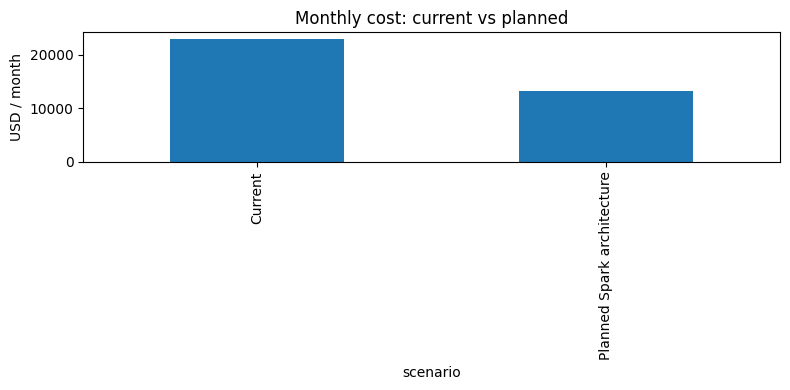

In [10]:
comparison.plot(kind="bar", x="scenario", y="monthly_cost_usd", legend=False, figsize=(8, 4), title="Monthly cost: current vs planned")
plt.ylabel("USD / month")
plt.tight_layout()
plt.show()

In [11]:
component_mapping = pd.DataFrame([
    {"current_component": "EC2 GPU", "planned_component": "Spark GPU worker pool"},
    {"current_component": "Kubernetes nodes", "planned_component": "Spark CPU worker pool"},
    {"current_component": "S3", "planned_component": "S3 object storage"},
    {"current_component": "Data transfer", "planned_component": "Data transfer"},
    {"current_component": "Logging", "planned_component": "Logging"},
])

current_short = current_bill[["component", "monthly_cost_usd"]].rename(columns={"monthly_cost_usd": "current_usd"})
planned_short = planned_bill[["component", "monthly_cost_usd"]].rename(columns={"component": "planned_component", "monthly_cost_usd": "planned_usd"})

component_comparison = component_mapping.merge(current_short, left_on="current_component", right_on="component", how="left").drop(columns=["component"])
component_comparison = component_comparison.merge(planned_short, on="planned_component", how="left")
component_comparison["delta_usd"] = component_comparison["planned_usd"] - component_comparison["current_usd"]
component_comparison

,current_component,planned_component,current_usd,planned_usd,delta_usd
0,EC2 GPU,Spark GPU worker pool,12000,4800.0,-7200.0
1,Kubernetes nodes,Spark CPU worker pool,4000,2600.0,-1400.0
2,S3,S3 object storage,3500,1890.0,-1610.0
3,Data transfer,Data transfer,2000,900.0,-1100.0
4,Logging,Logging,1500,450.0,-1050.0


## 6. Why Spark helps in FinOps terms

Spark by itself does **not** guarantee savings.  
The savings come from the **architecture patterns around Spark**:

1. **Elastic execution** instead of fixed application servers  
2. **Data locality** and reduced repeated movement of large datasets  
3. **Job scheduling** and separation of interactive vs batch workloads  
4. **GPU usage tied to job windows** instead of 24/7 reservation  
5. **Clear distinction between active data and historical data**


In [12]:
working_set_options = np.array([0.10, 0.15, 0.20, 0.25, 0.30])
gpu_reduction_options = np.array([0.30, 0.40, 0.50, 0.60])

rows = []
for ws in working_set_options:
    for gpu_reduction in gpu_reduction_options:
        active_tib = estimated_s3_tib * ws
        raw_hdfs_tib = active_tib * assumptions["hdfs_replication_factor"] / (1 - assumptions["hdfs_free_space_reserve_ratio"])
        hdfs_cost = assumptions["hdfs_cluster_monthly_cost_usd"] * (raw_hdfs_tib / raw_hdfs_needed_tib)

        total = (
            12000 * gpu_reduction +
            4000 * assumptions["cpu_cost_reduction_vs_current"] +
            3500 * assumptions["storage_cost_reduction_vs_current"] +
            2000 * assumptions["network_cost_reduction_vs_current"] +
            1500 * assumptions["logging_cost_reduction_vs_current"] +
            assumptions["control_plane_monthly_cost_usd"] +
            hdfs_cost
        )
        rows.append({
            "working_set_ratio": ws,
            "gpu_cost_fraction": gpu_reduction,
            "planned_total_usd": round(total, 0),
            "savings_pct": round((current_total - total) / current_total, 4)
        })

sensitivity = pd.DataFrame(rows)
sensitivity.head()

,working_set_ratio,gpu_cost_fraction,planned_total_usd,savings_pct
0,0.10,0.3,11357.0,0.5062
1,0.10,0.4,12557.0,0.4541
2,0.10,0.5,13757.0,0.4019
3,0.10,0.6,14957.0,0.3497
4,0.15,0.3,12090.0,0.4743


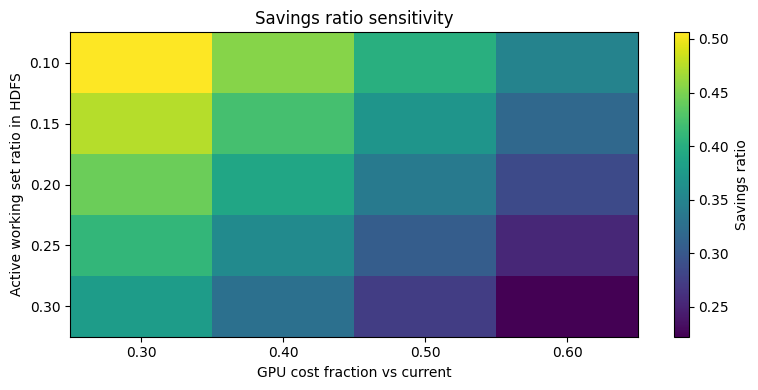

In [13]:
pivot = sensitivity.pivot(index="working_set_ratio", columns="gpu_cost_fraction", values="savings_pct")
plt.figure(figsize=(8, 4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(len(pivot.columns)), [f"{c:.2f}" for c in pivot.columns])
plt.yticks(range(len(pivot.index)), [f"{i:.2f}" for i in pivot.index])
plt.xlabel("GPU cost fraction vs current")
plt.ylabel("Active working set ratio in HDFS")
plt.title("Savings ratio sensitivity")
plt.colorbar(label="Savings ratio")
plt.tight_layout()
plt.show()

## 7. Final recommendation for the lesson

### Proposed transition target
A reasonable classroom target is:

- move from fixed app/Kubernetes nodes to **elastic Spark worker pools**
- keep **GPU nodes separate** and strictly schedule their use
- build **HDFS only for the active working set**
- keep the historical lake in **tiered S3**
- reduce transfer and log waste

### Example target monthly result
Using the assumptions in this notebook:

- current monthly spend: **$23,000**
- planned monthly spend: **about $13.4k–$14.0k**
- expected savings: roughly **35–42%**

This exceeds the exercise target of **20% cost reduction** while improving architectural scalability.


## 8. Discussion questions for students

1. Which assumption is the riskiest: **GPU usage**, **working set size**, or **network pattern**?  
2. When is **HDFS justified**, and when is S3 + table format enough?  
3. What should be measured before the migration:
   - job runtimes
   - daily volume processed
   - GPU duty cycle
   - shuffle size
   - cross-AZ traffic
   - log ingestion per service  
4. Which savings are “easy wins”, and which require **architectural redesign**?


## 9. Key takeaway

FinOps is not “how to make the bill smaller after deployment”.

It is a discipline of designing systems so that:

- expensive resources are **used intentionally**
- storage classes match **data temperature**
- scaling follows **workload reality**
- architecture decisions can be defended in both **technical** and **economic** terms
